<a href="https://colab.research.google.com/github/egemeenkaya/egemeenkaya.github.io/blob/master/Qwen2_5_LXT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Fix CUDA version mismatch between PyTorch and TorchAudio
!pip uninstall -y torchaudio
!pip install torch torchvision --upgrade -q
print("✓ PyTorch and TorchVision reinstalled cleanly")

# ── Step 1: Upload and unzip ──────────────────────────────────────────────────
from google.colab import files
print("Upload lxt-main.zip...")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]
!unzip -q "{zip_filename}" -d lxt_repo

# ── Step 2: Install dependencies ─────────────────────────────────────────────
!pip install -U transformers accelerate pillow qwen-vl-utils zennit torchvision -q

# ── Step 3: Install LXT from repo ──────────────────────────────────
!pip install ./lxt_repo/lxt -q
print("✓ LXT installed")

# ── Step 4: Patch installed LXT ───────────────────────────────────────────────
import lxt, os, sys, shutil

lxt_dir = os.path.dirname(lxt.__file__)
print(f"Patching installed LXT at: {lxt_dir}")

# Fix __init__.py — remove vilt and qwen3
path_init = os.path.join(lxt_dir, "efficient/models/__init__.py")
with open(path_init) as f:
    content = f.read()
content = content.replace("import lxt.efficient.models.vilt as vilt\n", "")
content = content.replace("    vilt.modeling_vilt: vilt.attnLRP,\n", "")
content = content.replace("import lxt.efficient.models.qwen3 as qwen3\n", "")
content = content.replace("    qwen3.modeling_qwen3: qwen3.attnLRP,\n", "")
with open(path_init, "w") as f:
    f.write(content)
print("✓ Patched LXT __init__.py")

# Fix bert.py — replace broken transformers 5.x imports with stubs
path_bert = os.path.join(lxt_dir, "efficient/models/bert.py")
with open(path_bert) as f:
    bert_content = f.read()
broken_bert = (
    "from transformers.pytorch_utils import "
    "apply_chunking_to_forward, find_pruneable_heads_and_indices, prune_linear_layer"
)
stubs = """import torch
import torch.nn as nn

def apply_chunking_to_forward(forward_fn, chunk_size, chunk_dim, *input_tensors):
    if chunk_size == 0:
        return forward_fn(*input_tensors)
    chunks = [t.split(chunk_size, dim=chunk_dim) for t in input_tensors]
    return torch.cat([forward_fn(*chunk) for chunk in zip(*chunks)], dim=chunk_dim)

def find_pruneable_heads_and_indices(heads, n_heads, head_size, already_pruned):
    mask = torch.ones(n_heads, head_size)
    heads = set(heads) - already_pruned
    for head in heads:
        head -= sum(1 if h < head else 0 for h in already_pruned)
        mask[head] = 0
    mask = mask.view(-1).contiguous().eq(1)
    index = torch.arange(len(mask))[mask].long()
    return heads, index

def prune_linear_layer(layer, index, dim=0):
    W = layer.weight.index_select(dim, index).clone().detach()
    new_layer = nn.Linear(W.size(1), W.size(0), bias=layer.bias is not None)
    new_layer.weight = nn.Parameter(W)
    if layer.bias is not None:
        new_layer.bias = nn.Parameter(layer.bias[index].clone().detach())
    return new_layer"""
if broken_bert in bert_content:
    bert_content = bert_content.replace(broken_bert, stubs)
    with open(path_bert, "w") as f:
        f.write(bert_content)
    print("✓ Patched LXT bert.py")
else:
    print("✓ LXT bert.py already clean")

# Copy qwen2_5_vl.py from university repo into installed location
src = "lxt_repo/lxt/lxt/efficient/models/qwen2_5_vl.py"
dst = os.path.join(lxt_dir, "efficient/models/qwen2_5_vl.py")
if os.path.exists(src):
    shutil.copy(src, dst)
    print("✓ Copied qwen2_5_vl.py to installed LXT")
else:
    print("✗ qwen2_5_vl.py not found in zip")

# ── Step 5: Patch transformers modeling_qwen2_5_vl.py ────────────────────────
import transformers, re

transformers_dir = os.path.dirname(transformers.__file__)
model_file = os.path.join(
    transformers_dir,
    "models/qwen2_5_vl/modeling_qwen2_5_vl.py"
)

with open(model_file) as f:
    tf_content = f.read()

# Replace ALL occurrences of ALL_ATTENTION_FUNCTIONS.get_interface(...)
pattern     = r'ALL_ATTENTION_FUNCTIONS\.get_interface\([^)]+\)'
matches     = re.findall(pattern, tf_content)
tf_content  = re.sub(pattern, 'eager_attention_forward', tf_content)

# Disable flash attention check so it always uses eager path
tf_content = tf_content.replace(
    'if is_flash_attention_requested(self.config):',
    'if False:  # forced eager attention'
)

with open(model_file, "w") as f:
    f.write(tf_content)
print(f"✓ Patched transformers modeling_qwen2_5_vl.py ({len(matches)} get_interface calls replaced)")

# ── Step 6: Verify ────────────────────────────────────────────────────────────
print("\nFiles in installed LXT models directory:")
for f in sorted(os.listdir(os.path.join(lxt_dir, "efficient/models/"))):
    print(f"  {f}")

print("\n✓ All patches applied. Restart runtime now, then run from Cell 2.")

Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.

Saving lxt-main.zip to lxt-main.zip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 143.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 149.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 74.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
✓ LXT installed
Patching i

--------------------------------------------------
IMPORTS AND MONKEY PATCH

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms.v2.functional import pil_to_tensor
from transformers import AutoProcessor
from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl
from lxt.efficient import monkey_patch, monkey_patch_zennit
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules


monkey_patch(modeling_qwen2_5_vl, verbose=True)
monkey_patch_zennit(verbose=True)

print("LXT patches applied.")

Patched Qwen2MLP
Patched Qwen2_5_VLMLP
Patched Qwen2RMSNorm
Patched Dropout
Patched transformers.models.qwen2_5_vl.modeling_qwen2_5_vl
Patched GELU
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward
LXT patches applied.


--------------------------------------------------
LOAD MODEL

In [ ]:
from transformers import AutoProcessor, BitsAndBytesConfig
from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl
from lxt.efficient import monkey_patch, monkey_patch_zennit
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules
import torch

device   = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"

print("Loading processor...")
processor = AutoProcessor.from_pretrained(model_id)

print("Loading model...")
model = modeling_qwen2_5_vl.Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map=device,
    torch_dtype=torch.bfloat16,
    attn_implementation="eager",
)

for param in model.parameters():
    param.requires_grad = False

composite = LayerMapComposite([
    (torch.nn.Conv3d,  z_rules.Gamma(0.1)),
    (torch.nn.Linear,  z_rules.Gamma(0.1)),
])
composite.register(model.model.visual)

model.eval()
print("Model ready.")

Loading processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/57.6k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model ready.


--------------------------------------------------
UPLOAD IMAGE

In [ ]:
from google.colab import files

print("Upload your CLEVR image...")
uploaded = files.upload()
image_filename = list(uploaded.keys())[0]
print(f"Uploaded: {image_filename}")

Upload your CLEVR image...


Saving CLEVR_val_010854.png to CLEVR_val_010854.png
Uploaded: CLEVR_val_010854.png


--------------------------------------------------
PREPARE INPUTS

In [ ]:
image_pil = Image.open(image_filename).convert("RGB")
question  = "There Is a cylinder that is left of the large matte object that is on the right side of the large gray thing, are there any tiny shiny spheres In front of It?"

# Convert image to tensor WITH requires_grad=True
# so LXT can compute how much each pixel contributed to the answer
image_tensor = pil_to_tensor(image_pil).float().to(device).requires_grad_(True)

prompt = [
    {
        "role": "system",
        "content": [{"type": "text", "text": (
            #"You are a careful visual reasoning assistant. "
            #"Reason step by step, then
            "One word answer."
        )}],
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_tensor},
            {"type": "text", "text": (
                f"Question: {question}\n\n"
                "One word answer."
            )},
        ],
    },
]

inputs = processor.apply_chat_template(
    prompt,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
).to(device)

print(f"Inputs prepared. Token count: {inputs['input_ids'].shape[1]}")

Inputs prepared. Token count: 247


--------------------------------------------------
GENERATE REASONING

In [ ]:
print("Generating reasoning...\n")

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=500,
        do_sample=False,
    )

new_tokens = output_ids[0][inputs["input_ids"].shape[-1]:]
response   = processor.decode(new_tokens, skip_special_tokens=True)

print("── Model response ──────────────────────────────────")
print(response)
print("────────────────────────────────────────────────────")

Generating reasoning...

── Model response ──────────────────────────────────
No
────────────────────────────────────────────────────


--------------------------------------------------
COMPUTE LXT RELEVANCE

In [ ]:
print("Computing LXT relevance...")

# Recompute the forward pass to get gradients
# generate() doesn't return logits so we need a separate forward pass
# We use output_ids[:, :-1] as input to predict output_ids[:, 1:]
input_ids    = output_ids[:, :-1]
input_embeds = model.get_input_embeddings()(input_ids).requires_grad_(True)

logits = model(
    inputs_embeds   = input_embeds,
    pixel_values    = inputs.pixel_values,
    image_grid_thw  = inputs.image_grid_thw,
    attention_mask  = torch.ones_like(input_ids),
).logits

# Build a mask that covers ALL generated answer tokens
# This attributes relevance to the entire answer, not just one token
# which gives a more complete picture of what the model used
logit_mask    = torch.full_like(logits, 0)

answer_start = input_ids.shape[-1] - inputs.input_ids.shape[-1]

# Use only the very last generated token for attribution
last_token_id = output_ids[0, -1]
logit_mask[0, -1, last_token_id] = 1

#answer_length = input_ids.shape[-1] - inputs.input_ids.shape[-1]

#for i, token_id in enumerate(output_ids[0, -answer_length:]):
#    logit_mask[:, -answer_length + i - 1, token_id] = 1

# Backward pass — LXT propagates relevance through the patched layers
logits.backward(logits.detach() * logit_mask)

# Image relevance: each pixel's contribution to the answer
# Sum over colour channels to get a 2D spatial map
img_relevance = (image_tensor.detach() * image_tensor.grad.detach()).sum(0)

# Text relevance: each token's contribution
txt_relevance = (
    input_embeds.detach()[0] * input_embeds.grad.detach()[0]
).sum(-1)

# Normalise both to [-1, 1]
img_relevance = img_relevance / img_relevance.abs().max().clamp_min(1e-8)
txt_relevance = txt_relevance / txt_relevance.abs().max().clamp_min(1e-8)

print("Relevance computed.")
print(f"Image relevance shape: {img_relevance.shape}")
print(f"Text relevance shape:  {txt_relevance.shape}")

Computing LXT relevance...
Relevance computed.
Image relevance shape: torch.Size([320, 480])
Text relevance shape:  torch.Size([248])


--------------------------------------------------
VISUALISE IMAGE HEATMAP

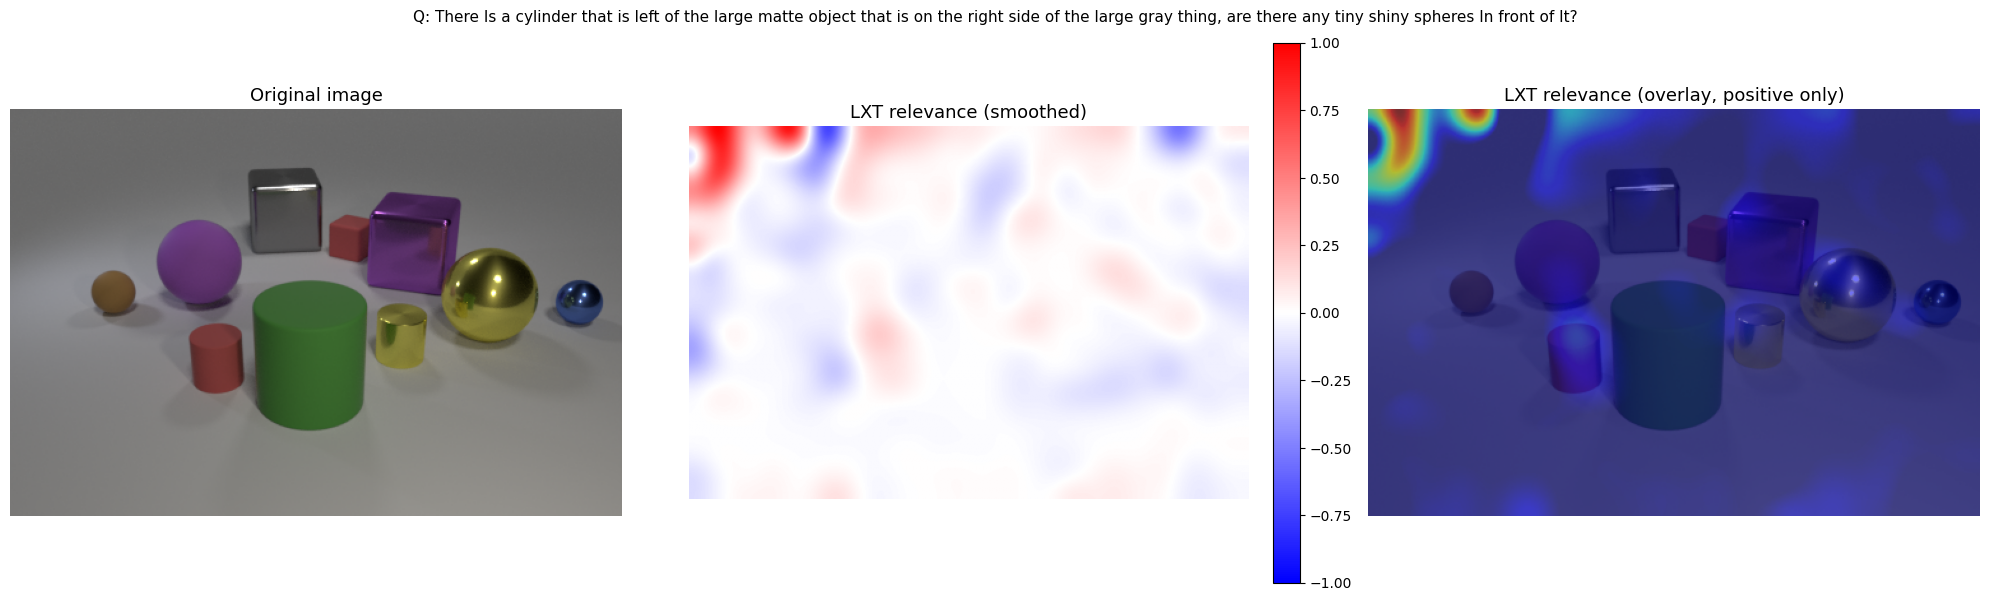

Saved: ai_output/lxt_heatmap.png
Saved: ai_output/lxt_img_relevance_raw.npy
Saved: ai_output/lxt_img_relevance_smooth.npy
Saved: ai_output/lxt_img_relevance_pos.npy
Human map shape: (1080, 1920)
AI map shape:    (320, 480)
Saved: ai_heatmap_for_spearman.npy  shape: (1080, 1920)
Both maps now: (1080, 1920) — ready for Spearman correlation


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from PIL import Image as PILImage

os.makedirs("ai_output", exist_ok=True)

# ── Get raw relevance ─────────────────────────────────────────────────────────
img_rel_np = img_relevance.detach().cpu().float().numpy()

# ── Smooth to turn scattered pixel dots into readable blobs ───────────────────
# sigma controls blob size — increase for smoother, decrease for more detail
img_rel_smooth = gaussian_filter(img_rel_np, sigma=15)

# Normalise to [-1, 1]
abs_max = np.abs(img_rel_smooth).max()
if abs_max > 0:
    img_rel_smooth = img_rel_smooth / abs_max

# Positive relevance only — for the overlay
# Positive = regions that drove the answer
# Negative = regions that suppressed it (less useful visually)
pos_rel = np.maximum(img_rel_smooth, 0)
if pos_rel.max() > 0:
    pos_rel = pos_rel / pos_rel.max()

# ── Upsample to image size ────────────────────────────────────────────────────
img_w, img_h = image_pil.size

h_pil_smooth = PILImage.fromarray(
    ((img_rel_smooth + 1) / 2 * 255).astype(np.uint8), mode='L'
)
h_pil_pos = PILImage.fromarray(
    (pos_rel * 255).astype(np.uint8), mode='L'
)

smooth_up = np.array(
    h_pil_smooth.resize((img_w, img_h), PILImage.BILINEAR)
) / 255.0 * 2 - 1   # back to [-1, 1]

pos_up = np.array(
    h_pil_pos.resize((img_w, img_h), PILImage.BILINEAR)
) / 255.0

# ── Overlay: blend positive relevance with original image ─────────────────────
h_col   = (plt.get_cmap("jet")(pos_up)[:, :, :3] * 255).astype(np.uint8)
img_np  = np.array(image_pil.convert("RGB"))
alpha   = 0.55
blended = (alpha * h_col + (1 - alpha) * img_np).astype(np.uint8)

# ── Three-panel figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: original image
axes[0].imshow(image_pil)
axes[0].set_title("Original image", fontsize=13)
axes[0].axis("off")

# Panel 2: smoothed raw relevance (blue=negative, red=positive)
im = axes[1].imshow(
    smooth_up, cmap="bwr", vmin=-1, vmax=1,
    interpolation="bilinear",
    extent=[0, img_w, img_h, 0]
)
axes[1].set_title("LXT relevance (smoothed)", fontsize=13)
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# Panel 3: positive relevance overlaid on image
axes[2].imshow(blended)
axes[2].set_title("LXT relevance (overlay, positive only)", fontsize=13)
axes[2].axis("off")

plt.suptitle(f"Q: {question}", fontsize=11)
plt.tight_layout()
plt.savefig("ai_output/lxt_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ai_output/lxt_heatmap.png")

# ── Save arrays ───────────────────────────────────────────────────────────────
np.save("ai_output/lxt_img_relevance_raw.npy",    img_rel_np)
np.save("ai_output/lxt_img_relevance_smooth.npy", img_rel_smooth)
np.save("ai_output/lxt_img_relevance_pos.npy",    pos_up)
print("Saved: ai_output/lxt_img_relevance_raw.npy")
print("Saved: ai_output/lxt_img_relevance_smooth.npy")
print("Saved: ai_output/lxt_img_relevance_pos.npy")

# For Spearman analysis — positive smooth relevance, same size as image
# This is directly comparable to human fixation density maps

pos_smooth = np.maximum(img_rel_smooth, 0)

# Normalise to [0, 1] so scale doesn't affect rank correlation
if pos_smooth.max() > 0:
    pos_smooth = pos_smooth / pos_smooth.max()

# Resize to match your human heatmap dimensions
# Check what size your human .npy files are first
human_map = np.load("subject12_q139824_density.npy")
print(f"Human map shape: {human_map.shape}")
print(f"AI map shape:    {pos_smooth.shape}")

# Resize AI map to match human map dimensions
from PIL import Image as PILImage
img_display_w, img_display_h = 1200, 800   # how big the image appears on screen
img_offset_x,  img_offset_y  = 360,  155   # where it sits on the 1920x1080 screen
# (use the correct y offset for this question's line count: 115, 155, or 195)

ai_pil = PILImage.fromarray((pos_smooth * 255).astype(np.uint8), mode='L')
ai_display = np.array(ai_pil.resize((img_display_w, img_display_h), PILImage.BILINEAR)) / 255.0

# Embed into full screen canvas at correct position
canvas = np.zeros((1080, 1920), dtype=np.float32)
canvas[img_offset_y : img_offset_y + img_display_h,
       img_offset_x : img_offset_x + img_display_w] = ai_display
if canvas.max() > 0:
    canvas /= canvas.max()

np.save("ai_output/ai_heatmap_for_spearman.npy", canvas)
print(f"Saved: ai_heatmap_for_spearman.npy  shape: {ai_resized.shape}")
print(f"Both maps now: {ai_resized.shape} — ready for Spearman correlation")

In [ ]:
from IPython.display import display, HTML
import numpy as np

# ── Colour function: blue (negative) → white (zero) → red (positive) ──────────
def score_to_hex(s):
    t = (float(s) + 1) / 2          # map [-1, 1] → [0, 1]
    t = max(0.0, min(1.0, t))
    if t < 0.5:
        f = t / 0.5
        r = int(30  + f * (245 - 30))
        g = int(100 + f * (245 - 100))
        b = int(200 + f * (245 - 200))
    else:
        f = (t - 0.5) / 0.5
        r = int(245 + f * (210 - 245))
        g = int(245 + f * (60  - 245))
        b = int(245 + f * (50  - 245))
    brightness = (0.299*r + 0.587*g + 0.114*b) / 255
    fg = '#2C2C2A' if brightness > 0.55 else '#F1EFE8'
    return f'rgb({r},{g},{b})', fg

# ── Build the HTML ─────────────────────────────────────────────────────────────
boxes = ""
for tok, rel in zip(q_tokens, q_rel):
    bg, fg = score_to_hex(rel)
    tok_display = tok.strip().replace("<", "&lt;").replace(">", "&gt;")
    if not tok_display:
        continue
    boxes += (
        f'<div title="{float(rel):.3f}" style="'
        f'background:{bg};color:{fg};'
        f'padding:6px 14px;border-radius:6px;'
        f'font-size:15px;font-family:monospace;font-weight:500;'
        f'display:inline-block;margin:3px;cursor:default">'
        f'{tok_display}</div>'
    )

# Legend
legend_steps = 40
gradient_stops = []
for i in range(legend_steps + 1):
    bg, _ = score_to_hex(i / legend_steps * 2 - 1)
    gradient_stops.append(bg)
gradient_css = ", ".join(gradient_stops)

html = f"""
<div style="padding:12px 0">
  <p style="font-size:13px;color:#888;margin:0 0 10px;font-family:sans-serif">
    Question token relevance &nbsp;|&nbsp; blue = negative &nbsp; white = neutral &nbsp; red = positive
  </p>
  <div style="display:flex;flex-wrap:wrap;gap:4px;margin-bottom:16px">
    {boxes}
  </div>
  <div style="display:flex;align-items:center;gap:8px;margin-top:4px">
    <span style="font-size:12px;color:#888;font-family:sans-serif">−1</span>
    <div style="height:10px;width:160px;border-radius:4px;
                background:linear-gradient(to right,{gradient_css});
                border:0.5px solid #ccc"></div>
    <span style="font-size:12px;color:#888;font-family:sans-serif">+1</span>
    <span style="font-size:12px;color:#888;font-family:sans-serif;margin-left:8px">relevance score</span>
  </div>
</div>
"""

display(HTML(html))

# Also save as a PNG using matplotlib for your thesis figures
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(max(10, len(q_tokens) * 0.9), 1.8))
ax.set_xlim(0, len(q_tokens))
ax.set_ylim(0, 1)
ax.axis('off')

for i, (tok, rel) in enumerate(zip(q_tokens, q_rel)):
    tok = tok.strip()
    if not tok:
        continue
    t      = (float(rel) + 1) / 2
    t      = max(0.0, min(1.0, t))
    if t < 0.5:
        f   = t / 0.5
        rgb = (30/255 + f*(215/255), 100/255 + f*(145/255), 200/255 + f*(45/255))
    else:
        f   = (t - 0.5) / 0.5
        rgb = (245/255 + f*(-35/255), 245/255 + f*(-185/255), 245/255 + f*(-195/255))

    brightness = 0.299*rgb[0] + 0.587*rgb[1] + 0.114*rgb[2]
    fg_col     = 'white' if brightness < 0.55 else '#2C2C2A'

    rect = mpatches.FancyBboxPatch(
        (i + 0.05, 0.1), 0.85, 0.8,
        boxstyle="round,pad=0.05",
        facecolor=rgb, edgecolor='none'
    )
    ax.add_patch(rect)
    ax.text(i + 0.475, 0.5, tok, ha='center', va='center',
            fontsize=11, color=fg_col, fontweight='bold')

plt.tight_layout(pad=0)
plt.savefig("ai_output/question_token_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ai_output/question_token_heatmap.png")

NameError: name 'q_tokens' is not defined

--------------------------------------------------
SAVE OUTPUTS

In [ ]:
import os, json

os.makedirs("ai_output", exist_ok=True)

np.save("ai_output/lxt_img_relevance.npy", img_rel_np)
np.save("ai_output/lxt_txt_relevance.npy", txt_relevance.detach().cpu().float().numpy())

with open("ai_output/reasoning.txt", "w") as f:
    f.write(response)

summary = {
    "model":    "Qwen/Qwen2.5-VL-7B-Instruct",
    "method":   "AttnLRP",
    "image":    image_filename,
    "question": question,
    "response": response,
}
with open("ai_output/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# Clean up composite rules when done
composite.remove()
print("Composite removed.")
print("\nSaved:")
print("  lxt_heatmap.png         ← visual")
print("  lxt_img_relevance.npy   ← spatial relevance for comparison with human heatmaps")
print("  lxt_txt_relevance.npy   ← token relevance")
print("  reasoning.txt           ← model reasoning text")
print("  summary.json            ← metadata")

Composite removed.

Saved:
  lxt_heatmap.png         ← visual
  lxt_img_relevance.npy   ← spatial relevance for comparison with human heatmaps
  lxt_txt_relevance.npy   ← token relevance
  reasoning.txt           ← model reasoning text
  summary.json            ← metadata
